In [ ]:
# RUN THIS CELL ONLY ONCE TO INITIALIZE THE LOCAL DATASET
%pip install ucimlrepo --quiet

import pandas as pd
import urllib.request
import zipfile
import os
from ucimlrepo import fetch_ucirepo

print("1. Fetching primary dataset via ucimlrepo...")
# Fetch dataset using the UCI ID
superconductivty_data = fetch_ucirepo(id=464)

# Reconstruct the full train.csv by concatenating features and targets
X = superconductivty_data.data.features
y = superconductivty_data.data.targets

train_df = pd.concat([X, y], axis=1)

# Export to a local CSV so the existing pd.read_csv('train.csv') commands work perfectly
train_df.to_csv('train.csv', index=False)
print("   -> Successfully generated 'train.csv'")

print("2. Fetching secondary composition dataset (unique_m.csv)...")
# Since ucimlrepo doesn't natively expose the secondary unique_m file in its data object,
# we securely pull the archive directly from the UCI servers to extract it.
uci_archive_url = "https://archive.ics.uci.edu/static/public/464/superconductivty+data.zip"
urllib.request.urlretrieve(uci_archive_url, "sc_data.zip")

with zipfile.ZipFile("sc_data.zip", 'r') as zip_ref:
    zip_ref.extract("unique_m.csv")

# Clean up the downloaded zip file to keep the repository pristine
os.remove("sc_data.zip")
print("   -> Successfully extracted 'unique_m.csv'")

print("\nSTATUS: ENVIRONMENT SECURED. All datasets are locally available. You may now run the notebooks unmodified.")

# 01 - Data Preprocessing and Anomaly Detection

In this notebook, we handle the initial data pipeline for our superconductivity dataset. This includes loading the data, standardizing the feature space, and executing two unsupervised anomaly detection techniques: One-Class SVM and Isolation Forest. 

We begin by importing the necessary libraries for data manipulation, machine learning, and visualization.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from time import time

from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

## Data Loading and Standardization

We load the primary dataset (`train.csv`) which contains 82 statistical features of elemental properties alongside the target `critical_temp`. To ensure scale-sensitive algorithms like the One-Class SVM perform optimally, we apply a standard scaler to the entire feature set.

In [6]:
df = pd.read_csv('train.csv')
features = df.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

print(f"Dataset shape: {df.shape}")

Dataset shape: (21263, 82)


## Anomaly Detection 1: One-Class SVM

We use a One-Class SVM with an RBF kernel to identify anomalies across all 82 high-dimensional features. Assuming an anomaly rate of roughly 1%, we set `nu=0.01`. After generating predictions, we isolate the anomalies, explicitly excluding materials with a critical temperature of 0.

In [7]:
start_time = time()
svm_model = OneClassSVM(kernel='rbf', nu=0.01)
svm_model.fit(X_scaled)
end_time = time()

print(f"SVM Training time: {end_time - start_time:.2f} seconds")

predictions = svm_model.predict(X_scaled)
df['svm_anomaly'] = predictions

anomalies = df[df['svm_anomaly'] == -1]
valid_anomalies = anomalies[anomalies['critical_temp'] != 0]

print(f"Anomalies detected (excluding Tc=0): {len(valid_anomalies)}")

SVM Training time: 0.38 seconds
Anomalies detected (excluding Tc=0): 215


## Dimensionality Reduction and SVM Visualization

Since we cannot plot 82 dimensions, we apply Principal Component Analysis (PCA) and t-Distributed Stochastic Neighbor Embedding (t-SNE) to reduce the data to 2 dimensions. We then map the SVM anomalies onto these lower-dimensional projections.

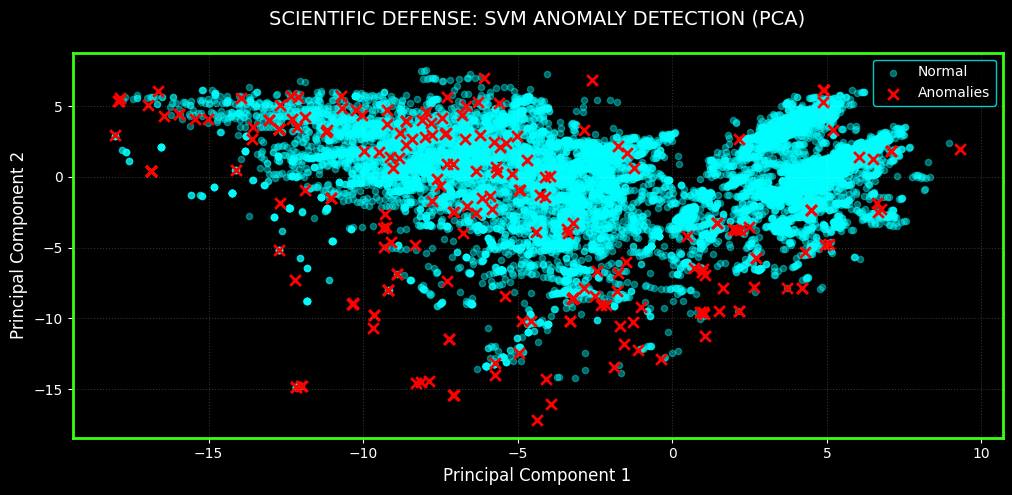

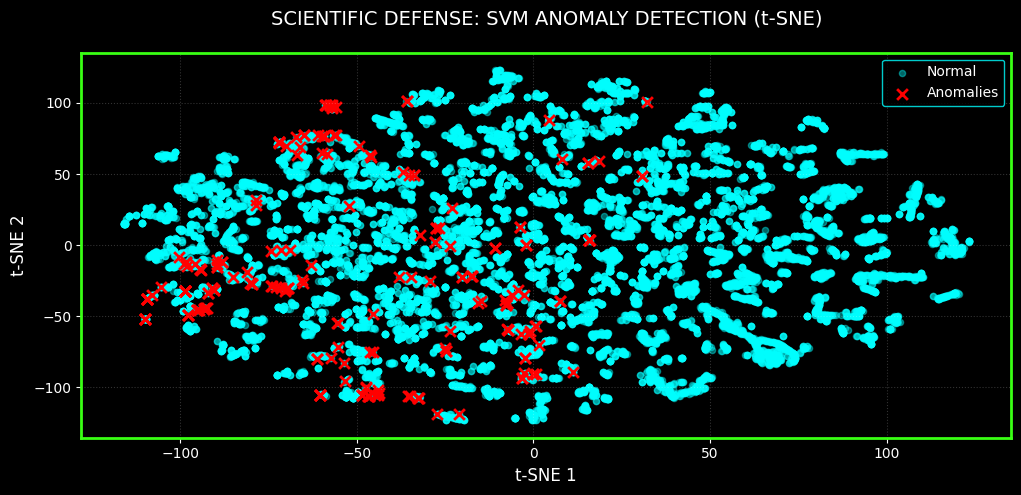

In [8]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['anomaly'] = df['svm_anomaly']

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
df_tsne = pd.DataFrame(X_tsne, columns=['t-SNE 1', 't-SNE 2'])
df_tsne['anomaly'] = df['svm_anomaly']

# PCA PLOT
plt.figure(figsize=(12, 5), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.scatter(df_pca[df_pca['anomaly'] == 1]['PC1'], df_pca[df_pca['anomaly'] == 1]['PC2'], 
            color='#00FFFF', label='Normal', alpha=0.4, s=20)
plt.scatter(df_pca[df_pca['anomaly'] == -1]['PC1'], df_pca[df_pca['anomaly'] == -1]['PC2'], 
            color='#FF0000', label='Anomalies', marker='x', s=60, linewidths=2)

plt.title("SCIENTIFIC DEFENSE: SVM ANOMALY DETECTION (PCA)", color='white', fontsize=14, pad=20)
plt.xlabel("Principal Component 1", color='white', fontsize=12)
plt.ylabel("Principal Component 2", color='white', fontsize=12)
ax.tick_params(axis='both', colors='white', labelsize=10)

for spine in ax.spines.values():
    spine.set_color('#39FF14') 
    spine.set_linewidth(2)

plt.legend(facecolor='black', labelcolor='white', edgecolor='#00FFFF')
plt.grid(True, linestyle=':', alpha=0.2, color='white')
plt.show()

# t-SNE PLOT
plt.figure(figsize=(12, 5), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.scatter(df_tsne[df_tsne['anomaly'] == 1]['t-SNE 1'], df_tsne[df_tsne['anomaly'] == 1]['t-SNE 2'], 
            color='#00FFFF', label='Normal', alpha=0.4, s=20)
plt.scatter(df_tsne[df_tsne['anomaly'] == -1]['t-SNE 1'], df_tsne[df_tsne['anomaly'] == -1]['t-SNE 2'], 
            color='#FF0000', label='Anomalies', marker='x', s=60, linewidths=2)

plt.title("SCIENTIFIC DEFENSE: SVM ANOMALY DETECTION (t-SNE)", color='white', fontsize=14, pad=20)
plt.xlabel("t-SNE 1", color='white', fontsize=12)
plt.ylabel("t-SNE 2", color='white', fontsize=12)
ax.tick_params(axis='both', colors='white', labelsize=10)

for spine in ax.spines.values():
    spine.set_color('#39FF14') 
    spine.set_linewidth(2)

plt.legend(facecolor='black', labelcolor='white', edgecolor='#00FFFF')
plt.grid(True, linestyle=':', alpha=0.2, color='white')
plt.show()

## Anomaly Detection 2: Isolation Forest

For our final step, we execute a targeted anomaly detection using an Isolation Forest. Instead of all features, we restrict the algorithm to `mean_atomic_mass` and `critical_temp` (excluding 0K values). This identifies materials that exhibit an extraordinary critical temperature relative to their mass, facilitating deeper scientific validation.

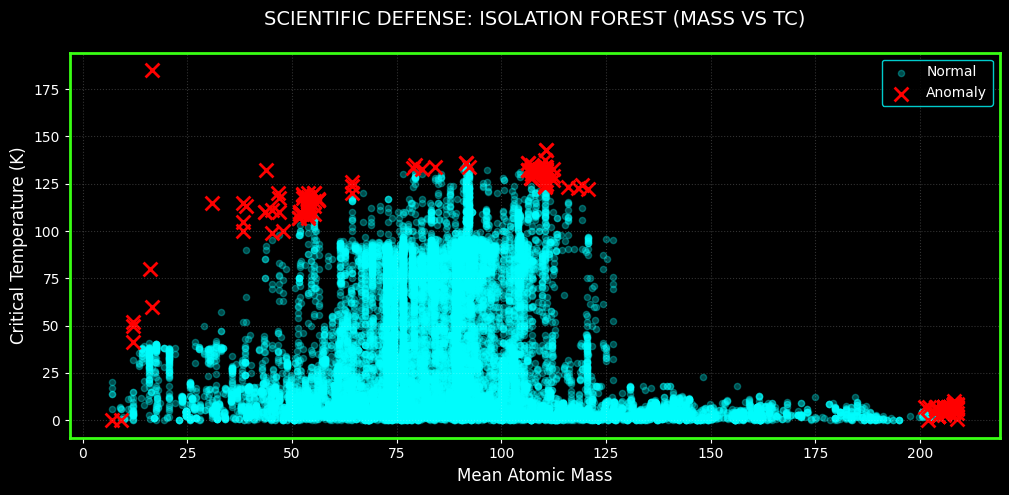

Isolation Forest anomalies: 212


In [9]:
def filter_critical_temp_zero(data_frame, target_features):
    return data_frame[data_frame['critical_temp'] != 0][target_features]

iso_features = ['mean_atomic_mass', 'critical_temp']
data_filtered = filter_critical_temp_zero(df.copy(), iso_features.copy())

iso_model = IsolationForest(contamination=0.01, random_state=42)
iso_model.fit(data_filtered)

df['iso_anomaly'] = iso_model.predict(df[iso_features])

plt.figure(figsize=(12, 5), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.scatter(df[df['iso_anomaly'] == 1]['mean_atomic_mass'], df[df['iso_anomaly'] == 1]['critical_temp'], 
            color='#00FFFF', label='Normal', alpha=0.3, s=20)
plt.scatter(df[df['iso_anomaly'] == -1]['mean_atomic_mass'], df[df['iso_anomaly'] == -1]['critical_temp'], 
            color='#FF0000', label='Anomaly', marker='x', s=100, linewidths=2)

plt.title("SCIENTIFIC DEFENSE: ISOLATION FOREST (MASS VS TC)", color='white', fontsize=14, pad=20)
plt.xlabel("Mean Atomic Mass", color='white', fontsize=12)
plt.ylabel("Critical Temperature (K)", color='white', fontsize=12)
ax.tick_params(axis='both', colors='white', labelsize=10)

for spine in ax.spines.values():
    spine.set_color('#39FF14') 
    spine.set_linewidth(2)

plt.legend(facecolor='black', labelcolor='white', edgecolor='#00FFFF')
plt.grid(True, linestyle=':', alpha=0.2, color='white')
plt.show()

print(f"Isolation Forest anomalies: {len(df[df['iso_anomaly'] == -1])}")